# Homework #8

## Negative effective mass density in acoustic metamaterials

Homework is based on https://www.sciencedirect.com/science/article/pii/S0020722508002279

### Discrete mass-spring system

The mechanism of the negative effective mass can be discovered by the structure shown below, where a hollow sphere with mass $M_0$ connects to a rigid sphere of mass $m$ via two massless, elastic springs with equal spring coeffiecent G.

![Screenshot 2025-04-22 155247.png](<attachment:Screenshot 2025-04-22 155247.png>)

By applying both Newton's second law, and Hooke's law. we get the equations of motion:

$$
\begin{cases}
m \ddot{x} = 2G (X - x) \\
M \ddot{x} = 2G (X - x)
\end{cases}
$$

If we then assume the system moves harmonically, we have $x(t) = x e^{i \omega t}$ and

$$
\ddot{x}(t) = x (i\omega)^2 e^{i\omega t} \;\Leftrightarrow\; \ddot{x}(t) = -\omega^2 x e^{i\omega t}
$$

which we can now substitute for $\ddot{x}$ on our system, considering $e^{i \omega t} = 1$. Solving the equation for $x$:

$$
-m \omega^2 x = 2G (X - x) \;\Leftrightarrow\; 2GX + m \omega^2 x - 2Gx = 0 \;\Leftrightarrow\; 2GX = 2Gx - m \omega^2 x \;\Leftrightarrow\; \frac{2GX}{m} = (\frac{2G}{m} - \omega^2)x \;\Leftrightarrow\; \frac{\frac{2G}{m}}{\frac{2G}{m} - \omega^2} = \frac{x}{X}
$$

With $w_1 = \sqrt{\frac{2G}{m}}$, we get

$$
\frac{\omega_1^2}{\omega_1^2 - \omega} = \frac{x}{X}
$$

The composite hollow shell can be considered as an equivalent solid object and the effective mass $M_{\text{eff}}$ of the unit can be defined as the total momentum divided by the velocity of the outer mass:

$$
M_{\text{eff}} = \frac{\rho_\text{total}}{\dot{x}} \;\Leftrightarrow\; M_{\text{eff}} = \frac{m\dot{x} + M_0\dot{X}}{\dot{X}} \;\Leftrightarrow\; M_{\text{eff}} = M_0 + \frac{m\dot{x}}{\dot{X}}
$$

Solving both $\dot{x}$ and $\dot{X}$, once again considering $e^{i \omega t} = 1$ we can then plug them in the equation above:

$$
\dot{x} = i \omega xe^{i \omega t}; \quad \dot{X} = i \omega Xe^{i \omega t};
$$

$$
M_{\text{eff}} = M_0 + m \frac{i \omega x}{i \omega X} \;\Leftrightarrow\; m_{\text{eff}} = M_0 + m \frac{x}{X} \;\Leftrightarrow\; M_{\text{eff}} = M_0 + m \frac{\omega_1^2}{\omega_1^2 - \omega}
$$

Due to the negative momentum of the inner mass overwhelming the system, $M_{\text{eff}}$ takes negative values at frequencies ranging from $\omega_0$ to $\omega_0 \sqrt{\frac{M_0 + m}{M_0}}$. We can also see:

$$
M_{\text{eff}} = M_0 + m \frac{\omega_1^2}{\omega_1^2 - \omega} \;\Leftrightarrow\; M_{\text{eff}} = M_0 + m \frac{\frac{2G}{m}}{\omega_1^2 - \omega^2} \;\Leftrightarrow\; M_{\text{eff}} = M_0(1 + \frac{\frac{2G}{M}}{\omega_1^2 - \omega^2})
$$

With $\omega_0 = \sqrt{\frac{2G}{M_0}}$:

$$
M_{\text{eff}} = M_0(1 + \frac{\omega_1^2}{\omega_1^2 - \omega^2})
$$

As $m \rightarrow \infty$, $\omega_1 \rightarrow 0$ and we get:

$$
M_{\text{eff}} = M_0(1 - \frac{\omega_0}{\omega^2})
$$
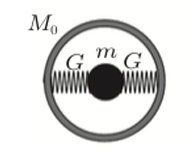

#### 1. After deriving each equation, plot the effective mass as a function $w$

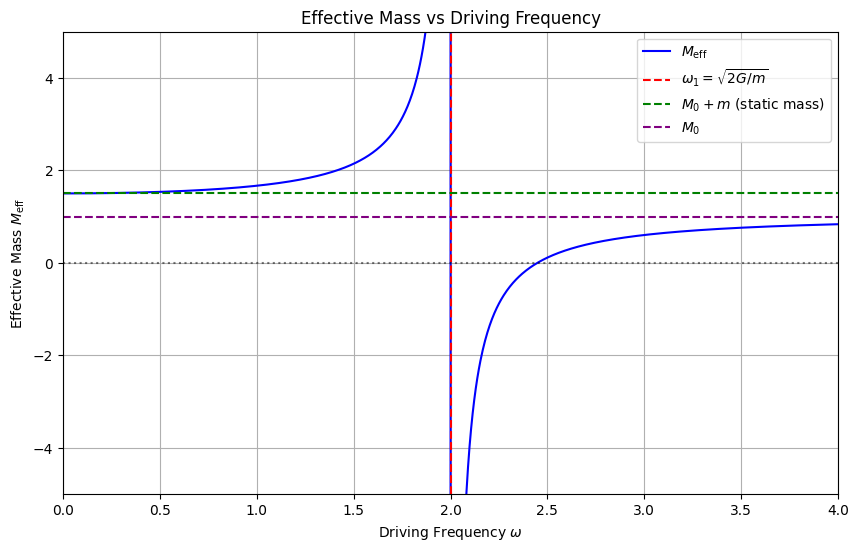

In [2]:
import numpy as np
import matplotlib.pyplot as plt

# Paramters
M_0 = 1.0
m = 0.5
G = 1.0
omega_1 = np.sqrt(2 * G / m)

# Frequency range
omega = np.linspace(0, 2 * omega_1, 1000)

M_eff = M_0 + m * omega_1**2 / (omega_1**2 - omega**2)

plt.figure(figsize=(10, 6))
plt.plot(omega, M_eff, label=r'$M_{\text{eff}}$', color='blue')
plt.axvline(x=omega_1, color='red', linestyle='--', label=r'$\omega_1 = \sqrt{2G/m}$')
plt.axhline(y=0, color='black', linestyle=':', alpha=0.5)
plt.axhline(y=M_0 + m, color='green', linestyle='--', label=r'$M_0 + m$ (static mass)')
plt.axhline(y=M_0, color='purple', linestyle='--', label=r'$M_0$')

plt.title('Effective Mass vs Driving Frequency')
plt.xlabel(r'Driving Frequency $\omega$')
plt.ylabel(r'Effective Mass $M_{\text{eff}}$')
plt.legend()
plt.grid(True)
plt.ylim(-5, 5)  # Adjust based on parameters
plt.xlim(0, 2 * omega_1)
plt.show()

At $\omega < \omega_1$, $M_{\text{eff}}$ is positive and increases as $\omega \rightarrow \omega_1$. Above $\omega_1$ $M_{\text{eff}}$ is negative, approaching $M_0$ as $\omega \rightarrow \infty$. This is the quality we wanted to study in a physical metamaterial system.

### Negative effective mass in lattices

For wave transmission, we consider an infinitely long one-dimensional lattice consisting of mass-in-mass lattice points as shown below.

![Screenshot 2025-04-22 200711.png](<attachment:Screenshot 2025-04-22 200711.png>)

The unit cells are placed periodically at a spacing $L$. The equations of motion for the $j$-th cell are given by 

$$
\begin{cases}
m_1^{(j)} \frac{d^2 u_1^{(j)}}{dt^2} + k_1 \left( 2u_1^{(j)} - u_1^{(j-1)} - u_1^{(j+1)} \right) + k_2 \left( u_1^{(j)} - u_2^{(j)} \right) = 0 \\
m_2^{(j)} \frac{d^2 u_2^{(j)}}{dt^2} + k_2 \left( u_2^{(j)} - u_1^{(j)} \right) = 0
\end{cases}
$$

where $u_1^{(j)}$ represents the displacement of mass "$\gamma$" in the $j$-th cell. The harmonic wave solution for the ($j + n$)th cell unit is given by:

$$
u_\gamma^{(j+n)} = B_\gamma e^{i(qx + nqL - \omega t)}
$$

where $B_\gamma$ is the complex wave amplitude, $q$ is the wave number, $\omega$ and $\gamma = 1, 2$.

$$
\begin{cases}
u_\gamma^{(j)} = B_\gamma e^{i(qx - \omega t)}, n = 0 \\
u_\gamma^{(j+n)} = B_\gamma e^{i(qx - \omega t)} e^{\pm inqL}, n = \pm 1
\end{cases}
$$

To continue we have to substitute $u_1^{(j)}$ and its second derivative in our equations of motion:

$$
\frac{d^2 u_\gamma^{(j+n)}}{dt^2} = (i\omega)^2 B_\gamma e^{i(qx + nqL -\omega t)} = -\omega^2 u_\gamma^{(j+n)}
$$

We then have:

$$
\begin{cases}
-m_1 \omega^2 u_1^j + k_1(2u_1^j - u_1^j e^{-iqL} - u_1^j e^{iqL}) + k_2(u_1^j - u_2^j) = 0 \\
-m_2 \omega^2 u_2^j + k_2(u_2^j - u_1^j) = 0
\end{cases}
$$

$$
\begin{cases}
-m_1 \omega^2 B_1 + k_1(2B_1 - B_1 e^{-iqL} - B_1 e^{iqL}) + k_2(B_1 - B_2) = 0 \\
-m_2 \omega^2 B_2 + k_2(B_2 - B_1) = 0
\end{cases}
$$

$$
\begin{cases}
((-m_1 \omega^2 + (2 - e^{-iqL} - e^{iqL}))k_1 + k_2)B_1 - k_2 B_2 = 0 \\
- k_2 B_1 + (k_2 - m_2 \omega^2)B_2 = 0
\end{cases}
$$

Where $-e^{-iqL} - e^{iqL} = - \frac{2(^{iqL} + e^{-iqL})}{2} = - 2 \cos{(qL)}$ and we get:

$$
\begin{cases}
(-m_1 \omega^2 + (2 - 2\cos{(qL)})k_1 + k_2)B_1 - k_2 B_2 = 0 \\
-k_2 B_1 + (-m_2 \omega^2 + k_2)B_2 = 0
\end{cases}
$$

Which can then be placed in a matrix, to calculate it's determinant:

$$
\begin{bmatrix}
 -m_1 \omega^2 + (2 - 2\cos(qL))k_1 + k_2 & -k_2 \\
 -k_2 & -m_2 \omega^2 + k_2
\end{bmatrix}
\begin{bmatrix}
 B_1 \\
 B_2
\end{bmatrix}
=
\begin{bmatrix}
 0 \\
 0
\end{bmatrix}
$$

Which gives:

$$
(-m_1 \omega^2 + (2 - 2\cos{(qL)})k_1 + k_2)(-m_2 \omega^2 + k_2) - k_2^2 = 0 \;\Leftrightarrow\; m_1 m_2 \omega^4 - m_1 \omega^2 k_2 - (2 - 2\cos{(qL)})k_1 m_2 \omega^2 + (2- 2\cos{(qL)}) k_1 k_2 - k_2 m_2 \omega^2 + k_2^2 - k_2^2 = 0 \;\Leftrightarrow\;
$$

$$
m_1 m_2 \omega^4 - (m_1 k_2 + (2 - 2\cos{(qL)})k_1 m_2 + k_2 m_2) \omega^2 + (2 - 2\cos{(qL)})k_1 k_2 = 0 \;\Leftrightarrow\; m_1 m_2 \omega^4 - ((m_1 + m_2) k_2 + 2m_2 k_1(1 - \cos{(qL)}))\omega^2 + 2k_1 k_2 (1 - \cos{(qL)}) = 0
$$
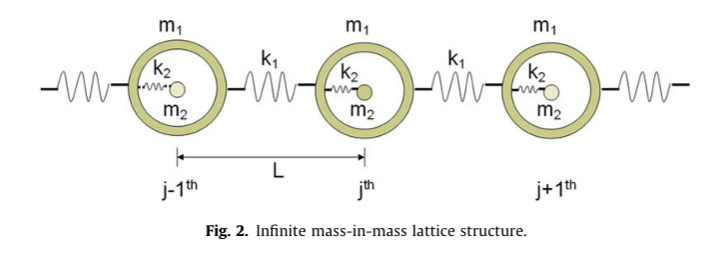

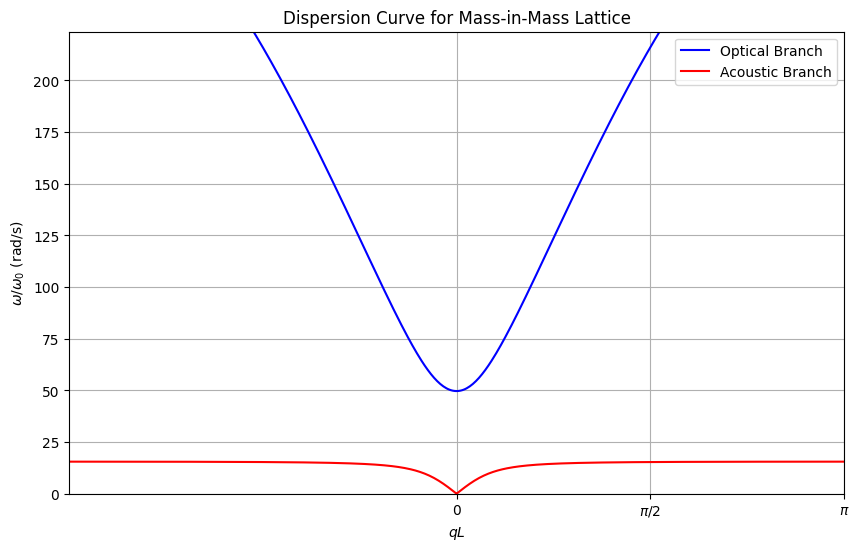

: 

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Parameters
m2_m1 = 9       # m2 / m1
k2_k1 = 0.1     # k2 / k1
w0 = 149.07     # Local resonance frequency (rad/s)

# Derived quantities
k1_m1 = 90 * w0**2  # k1 / m1 = 90 * w0^2

# Define the dispersion relation
def dispersion_relation(qL):
    cos_qL = np.cos(qL)
    A = 1 + 18 * (1 - cos_qL)
    discriminant = np.sqrt(A**2 - 7.2 * (1 - cos_qL))
    Omega2_plus = (A + discriminant) / 18
    Omega2_minus = (A - discriminant) / 18
    return np.sqrt(Omega2_plus), np.sqrt(Omega2_minus)

# Note: 18 (= 2 * m2/m1) is the coupling coefficient

# Wavenumber range (qL from 0 to pi)
qL = np.linspace(-np.pi, np.pi, 500)
Omega_plus, Omega_minus = np.zeros_like(qL), np.zeros_like(qL)

for i, q in enumerate(qL):
    Omega_plus[i], Omega_minus[i] = dispersion_relation(q)

# Convert to dimensional frequency (omega)
omega_plus = Omega_plus * w0
omega_minus = Omega_minus * w0

# Plotting
plt.figure(figsize=(10, 6))
plt.plot(qL, omega_plus, label='Optical Branch', color='blue')
plt.plot(qL, omega_minus, label='Acoustic Branch', color='red')
plt.xlabel('$qL$')
plt.ylabel('$\omega$/$\omega_0$ (rad/s)')
plt.title('Dispersion Curve for Mass-in-Mass Lattice')
plt.legend()
plt.grid(True)
plt.ylim(0, 1.5 * w0)
plt.xlim(-np.pi, np.pi)
plt.xticks([0, np.pi/2, np.pi], ['0', r'$\pi/2$', r'$\pi$'])
plt.show()

Next, consider an effective monatomic lattice system in which only effective masses $M_\text{eff}$ are connected by springs with spring constant k1. For this homogeneous lattice system the dispersion equation is readily obtained as:

$$
\omega^2 = \frac{2k_1(1-\cos{(qL)})}{M_\text{eff}}
$$

If this effective monatomic lattice system is equivalent to the original mass-in-mass lattice system, then the dispersion curves of the two systems must be identical. In other words, in Eq. (9) the effective mass meff must be selected so that the relation between x and qL is same as that for the original mass-in-mass system. This requirement is used to determine the effective mass. Using our previously established result for $M_\text{eff}$:

$$
M_\text{eff} = M_0 + m \frac{\omega_1^2}{\omega_1^2 - \omega^2}
$$

with:

$$
\begin{cases}
\omega_1 \equiv \omega_0 \\
M_0 \equiv m_1 \\
m \equiv m_2
\end{cases}
\quad and \quad m_\text{st} = m_1 + m_2
$$

We get:

$$
M_\text{eff} = m_1 + \frac{m_2 \omega_0^2}{\omega_0^2 - \omega^2} \;\Leftrightarrow\; m_1 + m_2 - m_2 + \frac{m_2 \omega_0^2}{\omega_0^2 - \omega^2} \;\Leftrightarrow\; M_\text{eff} = m_\text{st} - \frac{m_2(\omega_0^2 - \omega^2)}{\omega_0^2 - \omega^2} + \frac{m_2 \omega_0^2}{\omega_0^2 - \omega^2} \;\Leftrightarrow\; M_\text{eff} = m_\text{st} + \frac{m_2\omega^2}{\omega_0^2 - \omega^2} \;\Leftrightarrow\; M_\text{eff} = m_\text{st} + \frac{m_2 (\frac{\omega}{\omega_0})^2}{1 - (\frac{\omega}{\omega_0})^2}
$$

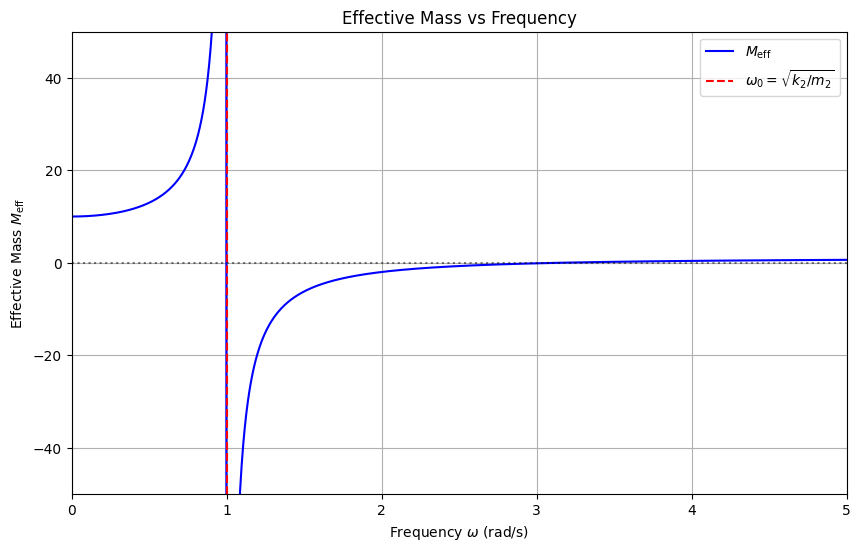

In [5]:
import numpy as np
import matplotlib.pyplot as plt

# Parameters
m1 = 1.0       # Mass of outer shell (M0)
m2 = 9.0       # Mass of inner sphere (m)
k2 = 0.1 * 90  # k2 = 0.1*k1, and k1 = 90 (derived earlier)
omega0 = np.sqrt(k2 / m2)  # Local resonance frequency

# Frequency range
omega = np.linspace(0, 5 * omega0, 1000)

# Effective mass calculation
Meff = m1 + (m2 * omega0**2) / (omega0**2 - omega**2)

# Plotting
plt.figure(figsize=(10, 6))
plt.plot(omega, Meff, label=r'$M_{\text{eff}}$', color='blue')
plt.axvline(x=omega0, color='red', linestyle='--', label=r'$\omega_0 = \sqrt{k_2/m_2}$')
plt.axhline(y=0, color='black', linestyle=':', alpha=0.5)
plt.title('Effective Mass vs Frequency')
plt.xlabel(r'Frequency $\omega$ (rad/s)')
plt.ylabel(r'Effective Mass $M_{\text{eff}}$')
plt.legend()
plt.grid(True)
plt.ylim(-50, 50)  # Adjust based on divergence
plt.xlim(0, 5 * omega0)
plt.show()